<a href="https://colab.research.google.com/github/tsolmon-gunaabazar/eye-disease-detection-deeplearning/blob/main/Eye_Disease_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Eye Disease Classification from OCT Scan Images using Deep Learning**

Eye diseases are the leading cause of vision loss around the world. Many of these diseases affect the retina and can be detected using medical imaging techniques such as Optical Coherence Tomography (OCT). OCT scans produce high-resolution cross-sectional images of the retina that allow doctors to observe structural changes in eye tissue \cite{kermany2018}. However, analyzing these scans requires time and specialized expertise, particularly because a large number of OCT scans are performed every year. Because of this, automated tools that can assist with identifying retinal diseases from OCT images could help reduce the workload for clinicians and support earlier detection of vision-threatening conditions. The goal of this project is to build a deep learning model that can automatically classify OCT images into four categories: *Normal*, *CNV (Choroidal Neovascularization)*, *DME (Diabetic Macular Edema)*, *Drusen*.

**Input**: an OCT eye scan image

**Output**: one of 4 labels:
1. CNV
2. DME
3. Drusen
4. Normal

The task can therefore be formulated as an image classification problem where the model maps an OCT image to one of four diagnostic labels.

In [1]:
# Importing libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
# Dataset
from google.colab import files
uploaded = files.upload()

Saving kermany2018.zip to kermany2018.zip


In [6]:
# Extracting files into a folder
!unzip -q kermany2018.zip -d /content/oct_data

In [7]:
# Preprocessing images
direction = "/content/oct_data"
img_size = 128
transform = transforms.Compose([transforms.Grayscale(num_output_channels=1), transforms.Resize((img_size, img_size)), transforms.ToTensor()]) #since the scans are mostly grayscale -> 1 channel

In [8]:
# Loading images and assigning labels
dataset = datasets.ImageFolder(direction, transform=transform)
print("Classes: ", dataset.classes)
print("Total images: ", len(dataset))

Classes:  ['CNV-samples', 'DME-samples', 'Drusen-samples', 'Normal-samples']
Total images:  4289


In [9]:
# Splitting datasets into training, validation, and testing
train_size = int(0.7*len(dataset)) # 70% training
valid_size = int(0.15*len(dataset)) # 15% validation
test_size = len(dataset) - train_size - valid_size # 15% testing

train_dataset, valid_dataset, test_dataset = random_split(dataset, [train_size, valid_size, test_size])
print("Train size: ", len(train_dataset))
print("Validation size: ", len(valid_dataset))
print("Test size: ", len(test_dataset))

Train size:  3002
Validation size:  643
Test size:  644


In [10]:
# DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) #shuffles datasets once every epoch
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

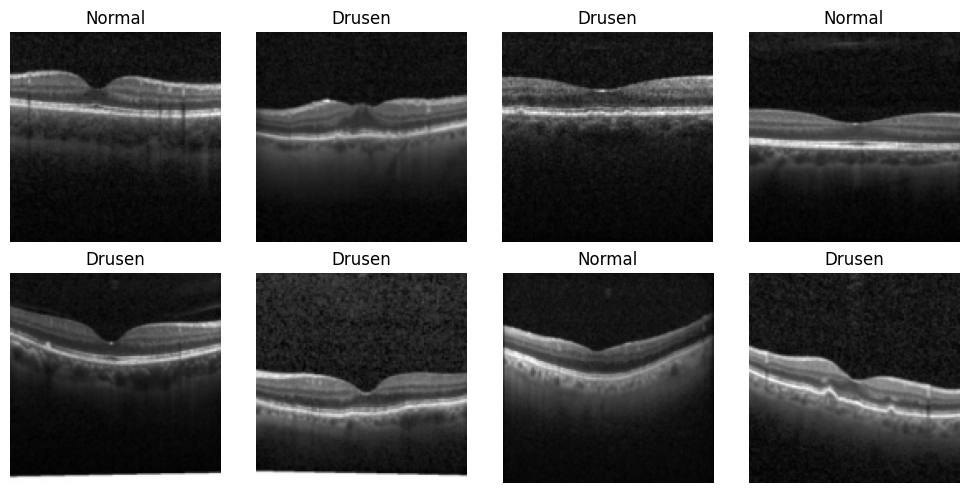

In [11]:
# Sample images (ignore)
pretty_class_names = ["CNV", "DME", "Drusen", "Normal"]
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
axes = axes.flatten()
for i in range(8):
  img=images[i].squeeze().numpy()
  axes[i].imshow(img, cmap="gray")
  axes[i].set_title(pretty_class_names[labels[i].item()])
  axes[i].axis("off")

plt.tight_layout()
plt.show()

    Class  Count
0     CNV   1245
1     DME    888
2  Drusen   1064
3  Normal   1092


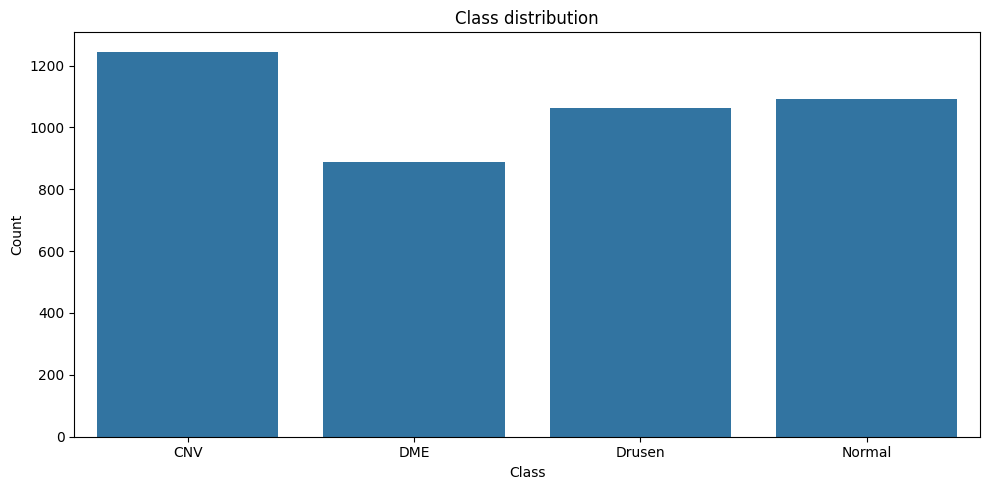

In [12]:
# Class distribution (ignore)
all_labels = [label for _, label in dataset.samples]
counts = Counter(all_labels)
class_counts = {pretty_class_names[k]: v for k, v in counts.items()}
dataframe_counts = pd.DataFrame(list(class_counts.items()), columns=["Class", "Count"])
print(dataframe_counts)

plt.figure(figsize=(10, 5))
sns.barplot(data=dataframe_counts, x="Class", y="Count")
plt.title("Class distribution")
plt.tight_layout()
plt.show()

In [13]:
# Baseline model using MLP
class baseline_mlp(nn.Module):
  def __init__(self, num_classes):
    super().__init__()
    self.model=nn.Sequential(nn.Flatten(), nn.Linear(128*128, 256), nn.ReLU(), nn.Linear(256, num_classes))
  def forward(self, x):
    return self.model(x)

In [15]:
# Evaluation model
def evaluate_model(model, loader, criterion):
  model.eval()
  total_loss = 0
  correct = 0
  total = 0
  all_labels = []
  all_predic = []

  with torch.no_grad(): #no gradients
    for images, labels in loader:
      images, labels = images.to(device), labels.to(device)
      outputs = model(images)
      loss = criterion(outputs, labels) #wrong predictions
      total_loss += loss.item()*images.size(0)
      _, predic = torch.max(outputs, 1) #pick highest score as prediction
      correct += (predic == labels).sum().item() #count correct predictions
      total += labels.size(0)
      all_labels.extend(labels.cpu().numpy())
      all_predic.extend(predic.cpu().numpy())

  avg_loss = total_loss/total
  accuracy = correct/total
  return avg_loss, accuracy, all_labels, all_predic

In [16]:
# Training
def train_model(model, train_loader, valid_loader, criterion, optimizer, epochs=5):
  history = {"train_loss": [], "train_accuracy": [], "valid_loss": [], "valid_accuracy": []}

  for epoch in range(epochs):
    model.train() #training mode on
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
      images, labels = images.to(device), labels.to(device)
      optimizer.zero_grad() #clear gradients
      outputs = model(images)
      loss = criterion(outputs, labels)
      loss.backward() #backpropagation step
      optimizer.step()
      running_loss += loss.item()*images.size(0)
      _, predic = torch.max(outputs, 1)
      correct += (predic == labels).sum().item()
      total += labels.size(0)

    train_loss = running_loss/total
    train_accuracy = correct/total
    valid_loss, valid_accuracy, _, _=evaluate_model(model, valid_loader, criterion)

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["valid_loss"].append(valid_loss)
    history["valid_accuracy"].append(valid_accuracy)

    print(f"Epoch {epoch+1}/{epochs} |"f"Train loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.4f} | " f"Validation loss: {valid_loss:.4f} | Validation Accuracy: {valid_accuracy:.4f}")

  return history

In [17]:
# Plot
def plot_history(history, title):
  epochs = range(1, len(history["train_loss"])+1)

  # Accuracy
  plt.figure(figsize=(10,5))
  plt.plot(epochs, history["train_accuracy"], label="Train Accuracy")
  plt.plot(epochs, history["valid_accuracy"], label="Validation Accuracy")
  plt.xlabel("Epochs")
  plt.ylabel("Accuracy")
  plt.title(f"{title} Accuracy")
  plt.legend()
  plt.tight_layout()
  plt.show()

  # Loss
  plt.figure(figsize=(10,5))
  plt.plot(epochs, history["train_loss"], label="Train loss")
  plt.plot(epochs, history["valid_loss"], label="Validation loss")
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.title(f"{title} Loss")
  plt.legend()
  plt.tight_layout()
  plt.show()

In [18]:
# Confusion Matrix
def plot_confus_matrix(y_true, y_predicted, class_names, filename):
  confus_mat = confusion_matrix(y_true, y_predicted)
  plt.figure(figsize=(10,5))
  sns.heatmap(confus_mat, annot=True, fmt="d", cmap="RdPu", xticklabels=class_names, yticklabels=class_names)
  plt.xlabel("Predicted")
  plt.ylabel("True")
  plt.title("Confusion Matrix")
  plt.tight_layout()
  plt.show()

In [19]:
baseline_model = baseline_mlp(num_classes=len(pretty_class_names)).to(device)

# Loss function
criterion = nn.CrossEntropyLoss() #lower=better
optimizer = optim.Adam(baseline_model.parameters(), lr=0.001)

baseline_history = train_model(baseline_model, train_loader, valid_loader, criterion, optimizer, epochs=15)
print(baseline_history)

Epoch 1/15 |Train loss: 1.5055 | Train Accuracy: 0.3061 | Validation loss: 1.3399 | Validation Accuracy: 0.3437
Epoch 2/15 |Train loss: 1.3227 | Train Accuracy: 0.3491 | Validation loss: 1.3156 | Validation Accuracy: 0.3904
Epoch 3/15 |Train loss: 1.2953 | Train Accuracy: 0.3871 | Validation loss: 1.3117 | Validation Accuracy: 0.3810
Epoch 4/15 |Train loss: 1.2540 | Train Accuracy: 0.4174 | Validation loss: 1.2734 | Validation Accuracy: 0.4121
Epoch 5/15 |Train loss: 1.2124 | Train Accuracy: 0.4507 | Validation loss: 1.2561 | Validation Accuracy: 0.4292
Epoch 6/15 |Train loss: 1.2033 | Train Accuracy: 0.4444 | Validation loss: 1.2724 | Validation Accuracy: 0.4308
Epoch 7/15 |Train loss: 1.1460 | Train Accuracy: 0.4897 | Validation loss: 1.1924 | Validation Accuracy: 0.4681
Epoch 8/15 |Train loss: 1.1095 | Train Accuracy: 0.5077 | Validation loss: 1.2134 | Validation Accuracy: 0.4712
Epoch 9/15 |Train loss: 1.0724 | Train Accuracy: 0.5213 | Validation loss: 1.1726 | Validation Accuracy:

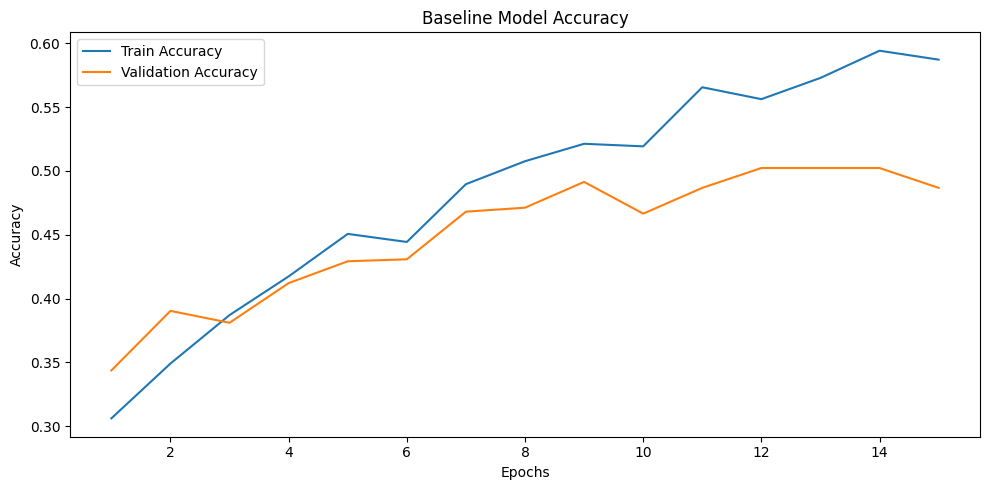

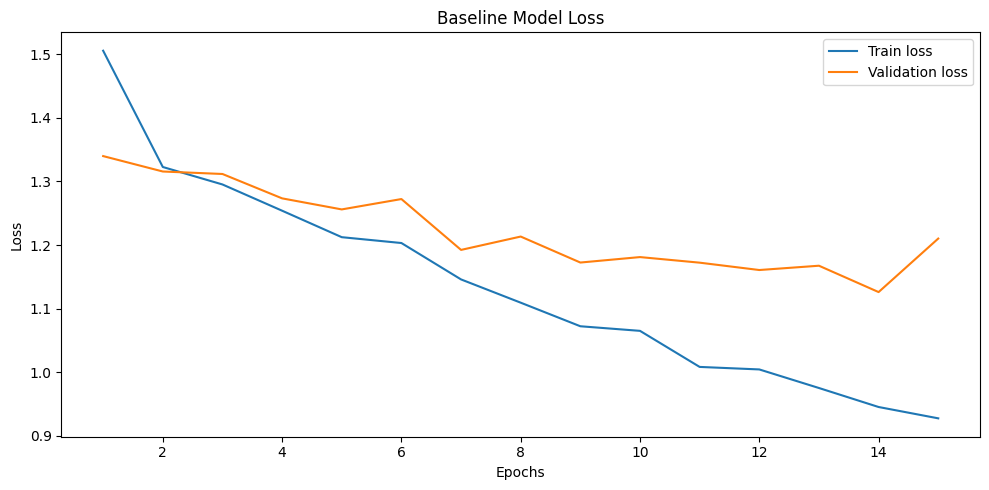

In [20]:
plot_history(baseline_history, "Baseline Model")

In [21]:
# Baseline evaluation
baseline_valid_loss, baseline_valid_accuracy, y_true_base, y_predicted_base = evaluate_model(baseline_model, valid_loader, criterion)
print("Baseline Validation Accuracy: ", baseline_valid_accuracy)
print(classification_report(y_true_base, y_predicted_base, target_names=pretty_class_names))

Baseline Validation Accuracy:  0.4867807153965785
              precision    recall  f1-score   support

         CNV       0.64      0.51      0.57       196
         DME       0.56      0.38      0.45       124
      Drusen       0.38      0.44      0.41       156
      Normal       0.44      0.59      0.50       167

    accuracy                           0.49       643
   macro avg       0.50      0.48      0.48       643
weighted avg       0.51      0.49      0.49       643



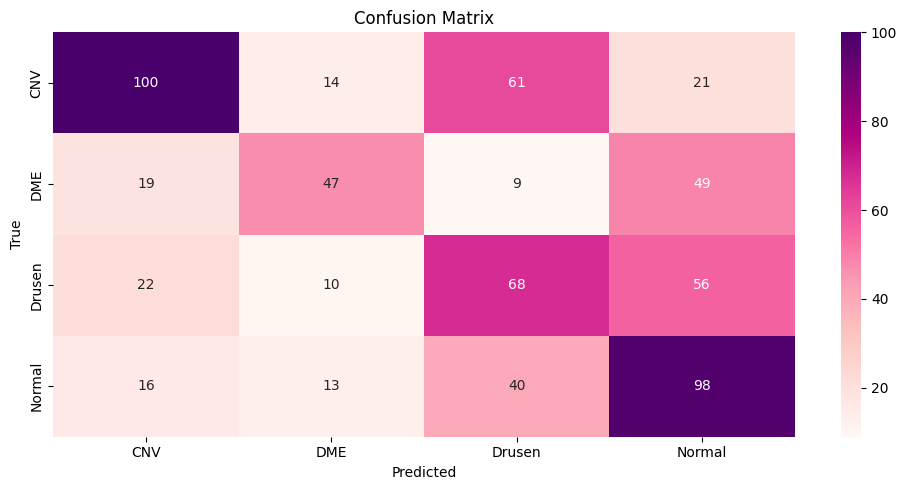

In [22]:
plot_confus_matrix(y_true_base, y_predicted_base, pretty_class_names, "baseline_confusion.png")

In [23]:
# Primary model (CNN)
# input shape = [1, 128, 128]
# after max pooling: 32*32 -> 16*16
# output: 64*16*16
class simple_cnn(nn.Module):
  def __init__(self, num_classes):
    super().__init__()
    self.conv = nn.Sequential(nn.Conv2d(1,16,kernel_size=3,padding=1), nn.ReLU(), nn.MaxPool2d(2), nn.Conv2d(16,32,kernel_size=3,padding=1), nn.ReLU(), nn.MaxPool2d(2), nn.Conv2d(32,64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2))
    self.fully_con = nn.Sequential(nn.Flatten(), nn.Linear(64*16*16, 128), nn.ReLU(), nn.Linear(128, num_classes))

  def forward(self, x):
    x = self.conv(x)
    x = self.fully_con(x)
    return x

In [24]:
# CNN model
cnn_model = simple_cnn(num_classes=len(dataset.classes)).to(device)
print(cnn_model)

simple_cnn(
  (conv): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fully_con): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=4, bias=True)
  )
)


In [26]:
# Training CNN
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)
cnn_history = train_model(cnn_model, train_loader, valid_loader, criterion, optimizer, epochs=15)

Epoch 1/15 |Train loss: 1.0256 | Train Accuracy: 0.5456 | Validation loss: 0.9730 | Validation Accuracy: 0.6205
Epoch 2/15 |Train loss: 0.8912 | Train Accuracy: 0.6329 | Validation loss: 0.8993 | Validation Accuracy: 0.6174
Epoch 3/15 |Train loss: 0.7871 | Train Accuracy: 0.6865 | Validation loss: 0.7932 | Validation Accuracy: 0.6703
Epoch 4/15 |Train loss: 0.6809 | Train Accuracy: 0.7288 | Validation loss: 0.8103 | Validation Accuracy: 0.6547
Epoch 5/15 |Train loss: 0.5778 | Train Accuracy: 0.7738 | Validation loss: 0.7405 | Validation Accuracy: 0.6750
Epoch 6/15 |Train loss: 0.4913 | Train Accuracy: 0.8115 | Validation loss: 0.7080 | Validation Accuracy: 0.7170
Epoch 7/15 |Train loss: 0.4296 | Train Accuracy: 0.8401 | Validation loss: 0.6674 | Validation Accuracy: 0.7325
Epoch 8/15 |Train loss: 0.3945 | Train Accuracy: 0.8411 | Validation loss: 0.7125 | Validation Accuracy: 0.7403
Epoch 9/15 |Train loss: 0.3006 | Train Accuracy: 0.8844 | Validation loss: 0.6552 | Validation Accuracy:

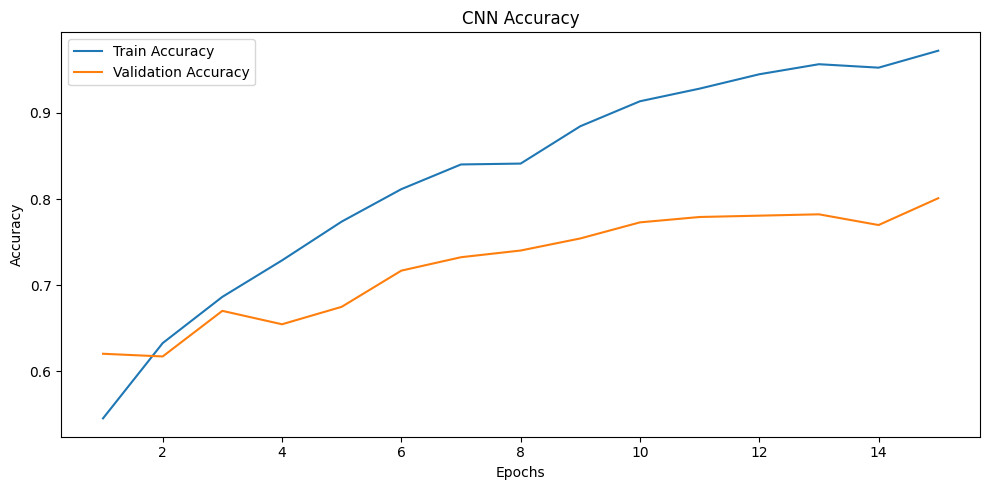

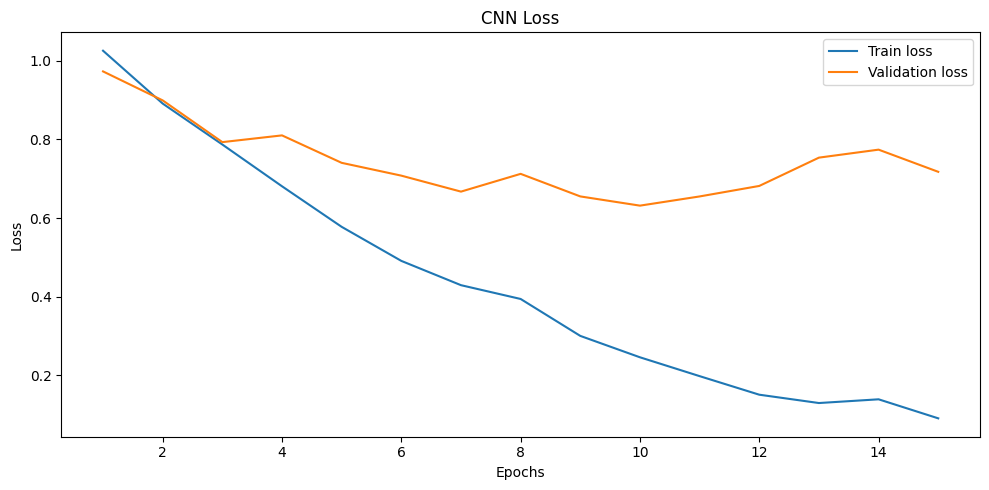

In [27]:
plot_history(cnn_history, "CNN")

In [28]:
# CNN evaluation
cnn_valid_loss, cnn_valid_accuracy, y_true_cnn, y_predicted_cnn = evaluate_model(cnn_model, valid_loader, criterion)
print("CNN Validation Accuracy: ", cnn_valid_accuracy)
print(classification_report(y_true_cnn, y_predicted_cnn, target_names=pretty_class_names))

CNN Validation Accuracy:  0.8009331259720062
              precision    recall  f1-score   support

         CNV       0.90      0.88      0.89       196
         DME       0.85      0.76      0.80       124
      Drusen       0.68      0.79      0.73       156
      Normal       0.78      0.74      0.76       167

    accuracy                           0.80       643
   macro avg       0.80      0.79      0.80       643
weighted avg       0.81      0.80      0.80       643



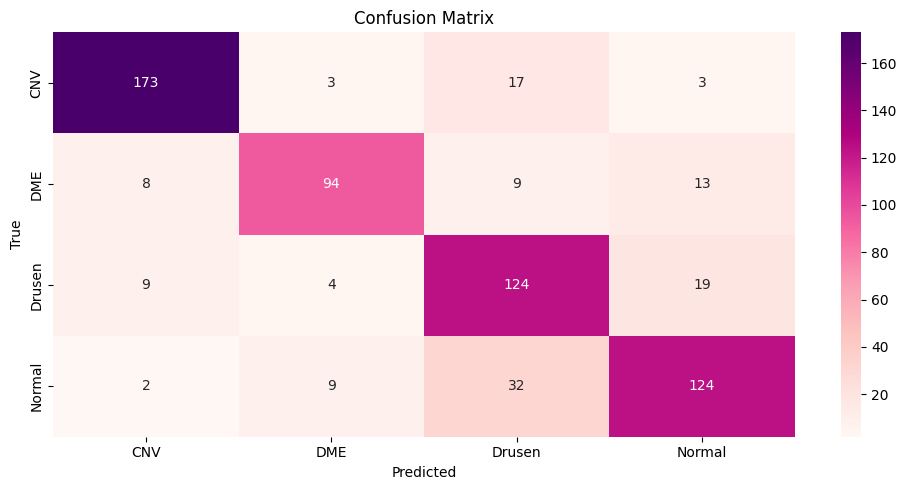

In [29]:
# Confusion Matrix
plot_confus_matrix(y_true_cnn, y_predicted_cnn, pretty_class_names, "cnn_confusion.png")

In [30]:
# Test evaluation
test_loss, test_accuracy, y_true_test, y_predicted_test = evaluate_model(cnn_model, test_loader, criterion)
print("Test Accuracy: ", test_accuracy)
print(classification_report(y_true_test, y_predicted_test, target_names=pretty_class_names))

Test Accuracy:  0.8105590062111802
              precision    recall  f1-score   support

         CNV       0.92      0.89      0.91       190
         DME       0.79      0.73      0.76       120
      Drusen       0.72      0.80      0.76       143
      Normal       0.79      0.79      0.79       191

    accuracy                           0.81       644
   macro avg       0.81      0.80      0.80       644
weighted avg       0.81      0.81      0.81       644



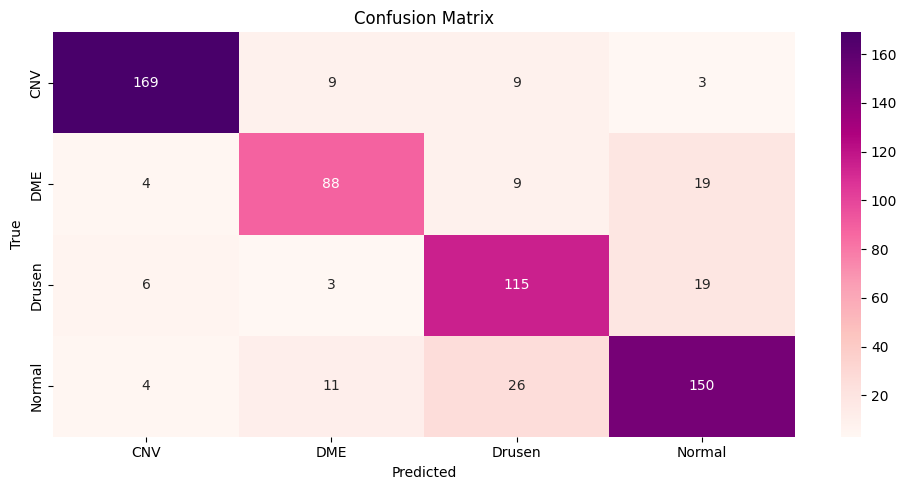

In [31]:
# Confusion matrix
plot_confus_matrix(y_true_test, y_predicted_test, pretty_class_names, "test_confusion.png")

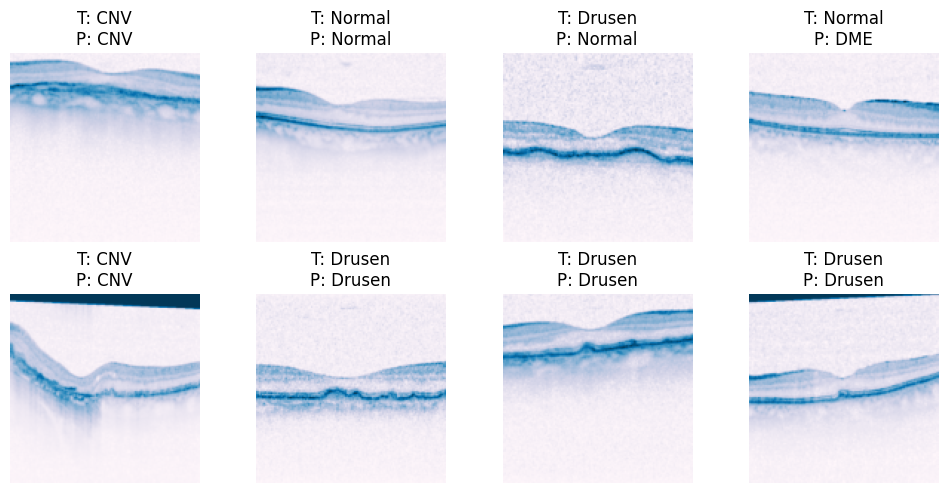

In [32]:
#ignore
cnn_model.eval()
images, labels = next(iter(valid_loader))
images = images.to(device)
with torch.no_grad():
  outputs = cnn_model(images)
  _, predic = torch.max(outputs, 1)

images = images.cpu()
labels = labels.cpu()
predic = predic.cpu()

figure, axes = plt.subplots(2,4,figsize=(10,5))
axes = axes.flatten()

for i in range(8):
  img=images[i].squeeze().numpy()
  axes[i].imshow(img, cmap="PuBu")
  axes[i].set_title(f"T: {pretty_class_names[labels[i]]}\nP: {pretty_class_names[predic[i]]}")
  axes[i].axis("off")
plt.tight_layout()
plt.show()

In [33]:
# Parameters
baseline_param = sum(p.numel() for p in baseline_model.parameters())
cnn_param = sum(p.numel() for p in cnn_model.parameters())
print("Baseline parameters: ", baseline_param)
print("CNN parameters: ", cnn_param)

Baseline parameters:  4195588
CNN parameters:  2121092
